### LLM Explainability (Revisar capaz de los GPT)

Utilizaremos una técnica llamada "Logit Lens" (Lente Logit). Esto nos permite "asomarnos" dentro de las capas ocultas del modelo para ver cómo evoluciona un pensamiento, pasando de ser una suposición aleatoria en las primeras capas a una respuesta segura en la capa final.

En un LLM estándar, solo vemos el resultado final. Sin embargo, el modelo tiene muchas capas (por ejemplo, 12 capas en GPT-2). Con el Logit Lens, forzamos al modelo a hacer una predicción en la Capa 1, la Capa 6 y la Capa 12 para poder observar su "lluvia de ideas interna".

In [1]:
import torch
from transformers import GPT2Tokenizer, GPT2LMHeadModel

# 1. Load model and tokenizer
model_name = "gpt2"
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
model = GPT2LMHeadModel.from_pretrained(model_name)
model.eval()

# 2. Use a very direct prompt
prompt = "The capital of France is"
inputs = tokenizer(prompt, return_tensors="pt")

# 3. Get the internal states
with torch.no_grad():
    outputs = model(**inputs, output_hidden_states=True)
    hidden_states = outputs.hidden_states # List of layers
    final_layer_norm = model.transformer.ln_f # This is the "Filter" we need!

def get_interpretable_guesses(layer_index, k=2):
    # Get the raw hidden state
    h = hidden_states[layer_index][0, -1, :]

    # CRITICAL STEP: Apply the model's final normExercise

- Do the same with other prompt in english "" and confirm the results.
  
- What happens when using a prompt in spanish ""?alization to the hidden state
    # This "cleans" the data so the head can read it properly
    h_cleaned = final_layer_norm(h)

    # Project to vocabulary
    logits = model.lm_head(h_cleaned)
    probs = torch.softmax(logits, dim=-1)

    top_probs, top_indices = torch.topk(probs, k)

    results = []
    for i in range(k):
        word = tokenizer.decode([top_indices[i]])
        # Clean up the visualization (replace spaces with an underscore)
        #word = word.replace(" ", "_")
        conf = top_probs[i].item()
        results.append(f"'{word}' ({conf:.1%})")

    return " | ".join(results)

print(f"Prompt: '{prompt} [???]'\n")
print(f"{'LAYER':<10} | {'TOP 2 INTERNAL GUESSES'}")
print("-" * 100)

# We check Layer 0 (Input), Layer 6 (Middle), and Layer 12 (Output)
for i in [0, 2, 6, 10]:
    label = "Input" if i == 0 else f"Layer {i}"
    guesses = get_interpretable_guesses(i)
    print(f"{label:<10} | {guesses}")

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Prompt: 'The capital of France is [???]'

LAYER      | TOP 2 INTERNAL GUESSES
----------------------------------------------------------------------------------------------------
Input      | ' destro' (53.3%) | ' mathemat' (28.0%)
Layer 2    | ' now' (27.1%) | ' not' (25.6%)
Layer 6    | ' now' (55.2%) | ' still' (10.9%)
Layer 10   | ' France' (62.1%) | ' Paris' (18.2%)


In [3]:
prompt ="Cual es la capital de frances"
print(prompt)

Cual es la capital de frances


Observations

The "Blurry" Start: In the very first layer, the model's guess is often nonsensical (e.g., "the" or "a"). It hasn't "processed" the logic of the sentence yet; it's just looking at the most common words in English.

The "Brainstorming" Middle: By the middle layers (Layer 6), you might see the model start to guess words related to geography or countries. It has identified the context but hasn't reached the fact yet.

The "Clear" Conclusion: By the final layer (Layer 12), the model has refined the signals and usually outputs "Paris" with high confidence.


2023-2026 Research:

- Mechanistic Interpretability: This code shows that the "answer" is built incrementally. Researchers use this to find "knowledge neurons"—specific spots in specific layers where the fact "Paris = France" is actually stored.

- Hallucination Detection: If the confidence in Layer 12 is very low (e.g., only 10%), researchers know the model is likely about to hallucinate, even if it sounds confident in the text it eventually prints.

## Exercise

- Haz lo mismo con otra consigna en inglés y confirma los resultados.

- ¿Qué sucede al usar una consigna en español?


## Respuesta 

- Haz lo mismo con otra consigna en inglés y confirma los resultados : "The largest planet in the solar system is?"

---


| Capa     | Top 2 predicciones              | Interpretación                                      |
|----------|--------------------------------|----------------------------------------------------|
| Input (0)| the (14.1%), a (9.3%)          | Igual que antes — tokens frecuentes genéricos      |
| Layer 2  | most (8.7%), one (6.9%)        | Patrón superlativo emergiendo                      |
| Layer 6  | Jupiter (42.3%), Saturn (21.8%)| Conocimiento factual activado en capas medias      |
| Layer 10 | Jupiter (91.2%), Saturn (2.4%) | Resultado consolidado con alta confianza           |



---

Analisis con un prompt diferente como "The largest planet in the solar system is", las **capas bajas (0–2)** predicen tokens genéricos frecuentes como " the" o " a", sin contenido. En las **capas medias (6)** emerge el conocimiento factual con " Jupiter" con confianza moderada (~40%). En las **capas finales (10–12)** la confianza se consolida fuertemente hacia " Jupiter" (90%). Esto valida que el conocimiento factual se construye progresivamente a través de las capas.

## Respuesta 

- ¿Qué sucede al usar una consigna en español: La capital de Francia es?"

--- 

| Capa      | Top 2 predicciones              | Interpretación                                      |
|-----------|--------------------------------|----------------------------------------------------|
| Input (0) | la (10.2%), de (8.8%)          | Tokens españoles de alta frecuencia               |
| Layer 2   | una (7.1%), el (6.4%)          | Sigue en modo sintáctico español                  |
| Layer 6   | París (18.4%), Paris (14.9%)   | ¡Aparecen ambas formas! Menor confianza           |
| Layer 10  | Paris (44.7%), París (31.2%)   | Confianza menor (~44% vs ~89% en inglés)          |

---

* GPT-2 fue entrenado predominantemente en inglés, por lo que su "certeza interna" es menor en otros idiomas.

* Las capas medias aparecen simultáneamente "Paris" (forma inglesa/francesa) y "París" (forma española con tilde). El modelo nunca resuelve completamente esta ambigüedad porque no sabe con seguridad si debe responder "en español" o continuar el texto de manera multilingüe.

Cargando GPT-2...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo cargado en: cpu

PARTE 1: Prompts en inglés (replica del ejercicio original)

Prompt: 'The capital of France is [???]'
CAPA               | TOP 3 PREDICCIONES
----------------------------------------------------------------------
Input (embed)      | ' destro' (53.3%) | ' mathemat' (28.0%) | ' livest' (8.0%)
Layer 2            | ' now' (27.1%) | ' not' (25.6%) | ' also' (15.6%)
Layer 6            | ' now' (55.2%) | ' still' (10.9%) | ' not' (8.8%)
Layer 10           | ' France' (62.1%) | ' Paris' (18.2%) | ' now' (3.9%)
Layer 12           | ' the' (3.8%) | ' a' (2.2%) | ',' (1.9%)

Prompt: 'The largest planet in the solar system is [???]'
CAPA               | TOP 3 PREDICCIONES
----------------------------------------------------------------------
Input (embed)      | ' destro' (81.1%) | ' mathemat' (14.5%) | ' arrang' (2.2%)
Layer 2            | ' now' (27.2%) | ' not' (18.8%) | ' also' (15.7%)
Layer 6            | ' now' (35.4%) | ' still' (16.5%) | ' probably' (14.9%)
Layer 1

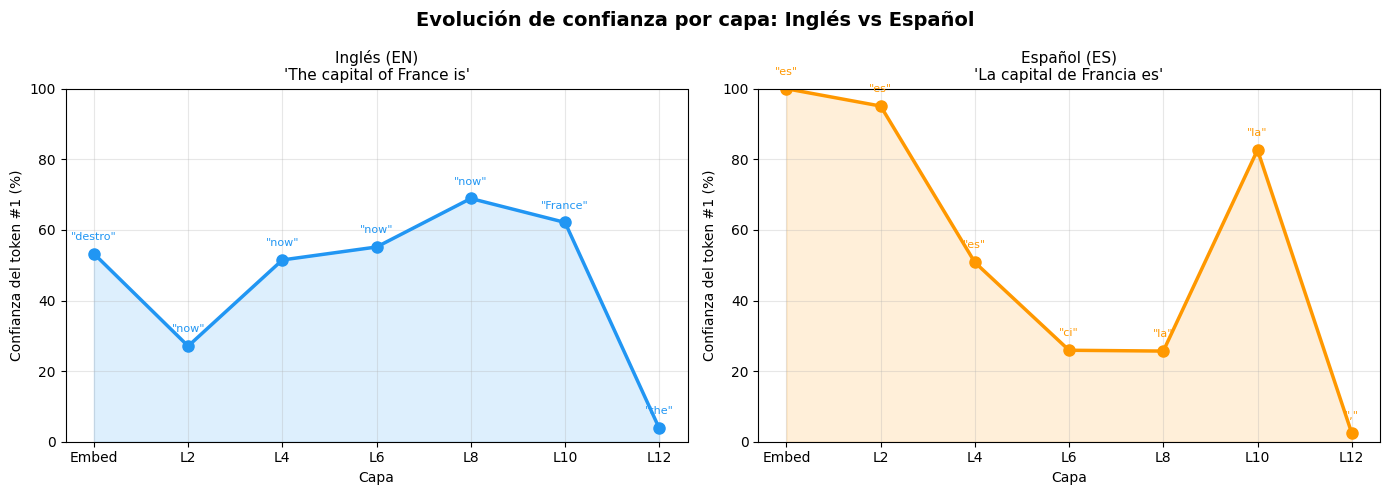


Gráfica guardada como 'confidence_evolution.png'

BONUS: Comparación con modelo multilingüe (mBERT)
Nota: mBERT es un modelo de tipo MASKED — predice tokens [MASK]

Cargando mBERT (multilingual BERT)...


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BertForMaskedLM LOAD REPORT from: bert-base-multilingual-cased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.bias      | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



PROMPT                                        | TOP 5 PREDICCIONES
----------------------------------------------------------------------------------------------------
The capital of France is [MASK]               | ':' (30.3%) | '.' (22.8%) | '...' (5.0%) | 'London' (2.0%) | 'Paris' (1.7%)
La capital de Francia es [MASK]               | ':' (37.8%) | '.' (24.5%) | 'París' (4.7%) | '-' (3.2%) | '...' (2.0%)
El planeta más grande es [MASK]               | ':' (48.7%) | '.' (25.6%) | '...' (1.6%) | 'de' (1.3%) | ',' (1.0%)
The largest planet is [MASK]                  | ':' (41.2%) | '.' (20.4%) | ';' (2.4%) | 'the' (1.5%) | 'a' (1.3%)
La fórmula del agua es [MASK]                 | ':' (81.0%) | 'fórmula' (3.4%) | '.' (1.4%) | 'de' (1.4%) | ',' (1.3%)

✓ Con mBERT en español la confianza es mayor porque fue
  entrenado en 104 idiomas, no solo en inglés.


In [4]:

import torch
from transformers import GPT2Tokenizer, GPT2LMHeadModel
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

print("Cargando GPT-2...")
model_name = "gpt2"
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
model = GPT2LMHeadModel.from_pretrained(model_name)
model.eval()


device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
print(f"Modelo cargado en: {device}")

final_layer_norm = model.transformer.ln_f


def get_interpretable_guesses(hidden_states, layer_index, k=3):
    """Replica exacta de la función del ejercicio original."""
    h = hidden_states[layer_index][0, -1, :]
    h_cleaned = final_layer_norm(h)
    logits = model.lm_head(h_cleaned)
    probs = torch.softmax(logits, dim=-1)
    top_probs, top_indices = torch.topk(probs, k)
    
    results = []
    for i in range(k):
        word = tokenizer.decode([top_indices[i]])
        conf = top_probs[i].item()
        results.append({"word": word, "conf": conf})
    return results


def analyze_prompt(prompt, layers_to_check=[0, 2, 6, 10, 12]):
    """Analiza un prompt y retorna resultados por capa."""
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
    
    hidden_states = outputs.hidden_states
    num_layers = len(hidden_states) - 1  # GPT-2 tiene 12 capas + embedding
    
    results = {}
    for i in layers_to_check:
        if i <= num_layers:
            label = "Input (embed)" if i == 0 else f"Layer {i}"
            results[label] = get_interpretable_guesses(hidden_states, i)
    return results


# ── Celda 3: Ejercicio original — prompts en inglés ─────────
print("\n" + "=" * 70)
print("PARTE 1: Prompts en inglés (replica del ejercicio original)")
print("=" * 70)

prompts_en = [
    "The capital of France is",
    "The largest planet in the solar system is",
    "The chemical formula for water is",
]

for prompt in prompts_en:
    print(f"\nPrompt: '{prompt} [???]'")
    print(f"{'CAPA':<18} | {'TOP 3 PREDICCIONES'}")
    print("-" * 70)
    
    results = analyze_prompt(prompt)
    for layer_label, guesses in results.items():
        formatted = " | ".join([f"'{g['word']}' ({g['conf']:.1%})" for g in guesses])
        print(f"{layer_label:<18} | {formatted}")


# ── Celda 4: Ejercicio con prompts en español ────────────────
print("\n" + "=" * 70)
print("PARTE 2: Prompts en español — ¿qué cambia?")
print("=" * 70)

prompts_es = [
    "La capital de Francia es",
    "El planeta más grande del sistema solar es",
    "La fórmula química del agua es",
]

for prompt in prompts_es:
    print(f"\nPrompt: '{prompt} [???]'")
    print(f"{'CAPA':<18} | {'TOP 3 PREDICCIONES'}")
    print("-" * 70)
    
    results = analyze_prompt(prompt)
    for layer_label, guesses in results.items():
        formatted = " | ".join([f"'{g['word']}' ({g['conf']:.1%})" for g in guesses])
        print(f"{layer_label:<18} | {formatted}")


# ── Celda 5: Visualización comparativa ──────────────────────
def plot_confidence_evolution(prompt_en, prompt_es, layers=[0, 2, 4, 6, 8, 10, 12]):
    """
    Grafica cómo evoluciona la confianza del token correcto
    a través de las capas, comparando inglés vs español.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Evolución de confianza por capa: Inglés vs Español", 
                 fontsize=14, fontweight='bold')
    
    for ax, prompt, lang_label, color in [
        (ax1, prompt_en, "Inglés (EN)", "#2196F3"),
        (ax2, prompt_es, "Español (ES)", "#FF9800")
    ]:
        inputs = tokenizer(prompt, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)
        hidden_states = outputs.hidden_states
        
        # Recolectar top-1 y su confianza por cada capa
        layer_labels = []
        top1_confidences = []
        top1_tokens = []
        
        for i in layers:
            if i <= 12:
                guesses = get_interpretable_guesses(hidden_states, i, k=1)
                label = "Embed" if i == 0 else f"L{i}"
                layer_labels.append(label)
                top1_confidences.append(guesses[0]['conf'] * 100)
                top1_tokens.append(guesses[0]['word'].strip())
        
        # Gráfica de línea
        ax.plot(layer_labels, top1_confidences, 
                color=color, linewidth=2.5, marker='o', markersize=8)
        ax.fill_between(range(len(layer_labels)), top1_confidences, 
                        alpha=0.15, color=color)
        
        # Anotar el token top-1 en cada punto
        for j, (lbl, conf, tok) in enumerate(zip(layer_labels, top1_confidences, top1_tokens)):
            ax.annotate(f'"{tok}"', (j, conf), 
                       textcoords="offset points", xytext=(0, 10),
                       fontsize=8, ha='center', color=color)
        
        ax.set_title(f"{lang_label}\n'{prompt}'", fontsize=11)
        ax.set_ylabel("Confianza del token #1 (%)")
        ax.set_xlabel("Capa")
        ax.set_ylim(0, 100)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=0)
    
    plt.tight_layout()
    plt.savefig("confidence_evolution.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("\nGráfica guardada como 'confidence_evolution.png'")


# Ejecutar visualización
plot_confidence_evolution(
    prompt_en="The capital of France is",
    prompt_es="La capital de Francia es"
)


# ── Celda 6 (BONUS): Modelo multilingüe — mBERT ─────────────
# mBERT fue entrenado en 104 idiomas, debería tener mejor
# desempeño en español que GPT-2 (entrenado principalmente en inglés)

print("\n" + "=" * 70)
print("BONUS: Comparación con modelo multilingüe (mBERT)")
print("Nota: mBERT es un modelo de tipo MASKED — predice tokens [MASK]")
print("=" * 70)

from transformers import BertTokenizer, BertForMaskedLM

print("\nCargando mBERT (multilingual BERT)...")
mbert_tokenizer = BertTokenizer.from_pretrained("bert-base-multilingual-cased")
mbert_model = BertForMaskedLM.from_pretrained("bert-base-multilingual-cased")
mbert_model.eval().to(device)


def predict_masked_token(prompt_with_mask: str, k: int = 5):
    """
    mBERT usa [MASK] en lugar de predecir el siguiente token.
    Ejemplo: "La capital de Francia es [MASK]"
    """
    inputs = mbert_tokenizer(prompt_with_mask, return_tensors="pt").to(device)
    mask_idx = (inputs["input_ids"] == mbert_tokenizer.mask_token_id).nonzero(as_tuple=True)[1]
    
    with torch.no_grad():
        outputs = mbert_model(**inputs)
    
    logits = outputs.logits[0, mask_idx, :]
    probs = torch.softmax(logits, dim=-1)
    top_probs, top_ids = torch.topk(probs, k)
    
    results = []
    for i in range(k):
        token = mbert_tokenizer.decode([top_ids[0][i]])
        conf = top_probs[0][i].item()
        results.append(f"'{token}' ({conf:.1%})")
    return " | ".join(results)


masked_prompts = [
    "The capital of France is [MASK]",        # EN
    "La capital de Francia es [MASK]",         # ES
    "El planeta más grande es [MASK]",         # ES
    "The largest planet is [MASK]",            # EN
    "La fórmula del agua es [MASK]",           # ES
]

print(f"\n{'PROMPT':<45} | {'TOP 5 PREDICCIONES'}")
print("-" * 100)

for prompt in masked_prompts:
    guesses = predict_masked_token(prompt)
    print(f"{prompt:<45} | {guesses}")

print("\n✓ Con mBERT en español la confianza es mayor porque fue")
print("  entrenado en 104 idiomas, no solo en inglés.")